# 02. Статистические модели через statsforecast

Сравнение 5 статистических методов прогнозирования временного ряда.

Используются:

- Naive;
- SeasonalNaive;
- RandomWalkWithDrift;
- AutoARIMA;
- AutoETS;
- AutoTheta;
- Prophet - опционально, если установлен.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebook':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.ts_pipeline import (
    load_series,
    infer_frequency,
    infer_season_length,
    split_series,
    to_nixtla_df,
    forecast_metrics,
)

REPORT_DIR = PROJECT_ROOT / 'reports'
FIG_DIR = REPORT_DIR / 'figures'
REPORT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
TARGET_PATH = PROJECT_ROOT / 'data' / 'raw' / 'international-airline-passengers.csv'
series = load_series(TARGET_PATH, name='airline_passengers')

freq = infer_frequency(series)
season_length = infer_season_length(series)
train, test = split_series(series, test_size=12)
h = len(test)

print('freq:', freq)
print('season_length:', season_length)
print('train:', train.index.min(), train.index.max(), len(train))
print('test:', test.index.min(), test.index.max(), len(test))

freq: MS
season_length: 12
train: 1949-01-01 00:00:00 1959-12-01 00:00:00 132
test: 1960-01-01 00:00:00 1960-12-01 00:00:00 12


/home/osboxes/Desktop/project_neto_time_completion/src/ts_pipeline.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed.loc[regular] = pd.to_datetime(text.loc[regular], errors="coerce")


Ряд распознан как месячный: `freq = MS`, то есть наблюдения идут с начала каждого месяца. Сезонная длина равна 12, что логично для помесячных данных: один полный сезон соответствует одному году.

Данные разбиты корректно для задачи прогнозирования временного ряда: обучающая часть включает период с января 1949 по декабрь 1959, а тестовая часть - последние 12 месяцев 1960 года. Такое разбиение сохраняет хронологический порядок и не допускает утечки будущей информации в обучение. Предупреждение `UserWarning` связано с автоматическим распознаванием формата даты и не влияет на саму логику разбиения.

In [3]:
train_df = to_nixtla_df(train, unique_id='airline_passengers')
full_df = to_nixtla_df(series, unique_id='airline_passengers')
train_df.head()

,unique_id,ds,y
0,airline_passengers,1949-01-01,112.0
1,airline_passengers,1949-02-01,118.0
2,airline_passengers,1949-03-01,132.0
3,airline_passengers,1949-04-01,129.0
4,airline_passengers,1949-05-01,121.0


Данные преобразованы в формат, который требуется библиотеке `statsforecast`: `unique_id` - идентификатор временного ряда, `ds` - дата наблюдения, `y` - значение ряда. В нашем случае ряд один, поэтому `unique_id` везде одинаковый: `airline_passengers`.

Первые строки: даты идут по месяцам, а значения пассажиропотока представлены числовым столбцом `y`. Значит, данные готовы для подачи в статистические модели.


In [4]:
from statsforecast import StatsForecast
from statsforecast.models import (
    Naive,
    SeasonalNaive,
    RandomWalkWithDrift,
    AutoARIMA,
    AutoETS,
    AutoTheta,
)

models = [
    Naive(),
    SeasonalNaive(season_length=season_length),
    RandomWalkWithDrift(),
    AutoARIMA(season_length=season_length),
    AutoETS(season_length=season_length),
    AutoTheta(season_length=season_length),
]

sf = StatsForecast(models=models, freq=freq, n_jobs=-1)
forecast_df = sf.forecast(df=train_df, h=h)
forecast_df

,unique_id,ds,Naive,SeasonalNaive,RWD,AutoARIMA,AutoETS,AutoTheta
0,airline_passengers,1960-01-01,405.0,360.0,407.236641,424.083784,406.651267,412.711879
1,airline_passengers,1960-02-01,405.0,342.0,409.473282,407.042331,401.732908,404.640500
2,airline_passengers,1960-03-01,405.0,406.0,411.709924,470.807713,456.289632,466.810896
3,airline_passengers,1960-04-01,405.0,396.0,413.946565,460.865139,440.870524,449.600403
4,airline_passengers,1960-05-01,405.0,420.0,416.183206,484.851083,440.333917,454.047790
5,airline_passengers,1960-06-01,405.0,472.0,418.419847,536.854524,496.866062,517.857791
6,airline_passengers,1960-07-01,405.0,548.0,420.656489,612.853682,545.839092,572.380178
7,airline_passengers,1960-08-01,405.0,559.0,422.893130,623.853888,544.672515,571.371659
8,airline_passengers,1960-09-01,405.0,463.0,425.129771,527.853837,477.034489,502.108036
9,airline_passengers,1960-10-01,405.0,407.0,427.366412,471.853850,412.423110,438.527151


In [5]:
# Оценка качества statsforecast-моделей.
metric_rows = []
model_cols = [c for c in forecast_df.columns if c not in ['unique_id', 'ds']]

for col in model_cols:
    metrics = forecast_metrics(test.values, forecast_df[col].values)
    metrics['model'] = col
    metrics['group'] = 'statistical'
    metric_rows.append(metrics)

stats_metrics = pd.DataFrame(metric_rows).sort_values('RMSE')
stats_metrics.to_csv(REPORT_DIR / 'statsforecast_comparison.csv', index=False)
stats_metrics

,MAE,RMSE,MAPE,sMAPE,model,group
3,18.515823,23.919484,4.179693,4.031179,AutoARIMA,statistical
5,19.357397,24.985161,3.919981,3.931008,AutoTheta,statistical
4,35.612471,40.083617,7.206838,7.450637,AutoETS,statistical
1,47.833333,50.708316,9.987533,10.571808,SeasonalNaive,statistical
2,66.307888,92.666363,12.417957,13.814045,RWD,statistical
0,76.000000,102.976535,14.251338,16.120845,Naive,statistical


### Вывод по метрикам качества

Лучшей моделью по `RMSE` стала `AutoARIMA`: RMSE = 23.92, MAE = 18.52, MAPE = 4.18%. Это означает, что модель дает наиболее низкую крупную ошибку среди проверенных статистических методов и хорошо подходит для данного ряда.

`AutoTheta` показала очень близкий результат: RMSE = 24.99, MAE = 19.36, MAPE = 3.92%. По процентным ошибкам она даже немного лучше `AutoARIMA`, но по RMSE уступает. Поэтому обе модели можно считать сильными кандидатами, а финальный выбор зависит от того, какая метрика важнее в задаче.

`Naive` показала худший результат среди статистических и baseline-моделей: RMSE = 102.98, MAE = 76.00, MAPE = 14.25%.

`SeasonalNaive` улучшила результат относительно `Naive`: RMSE снизился со 102.98 до 50.71, то есть на 52.27 пункта или на 50.8%. Это подтверждает, что годовая сезонность является важным фактором для ряда авиапассажиров.

Лучшей статистической моделью стала `AutoARIMA`: RMSE = 23.92, MAE = 18.52, MAPE = 4.18%. По сравнению с `SeasonalNaive` RMSE ниже на 26.79 пункта, или на 52.8%.

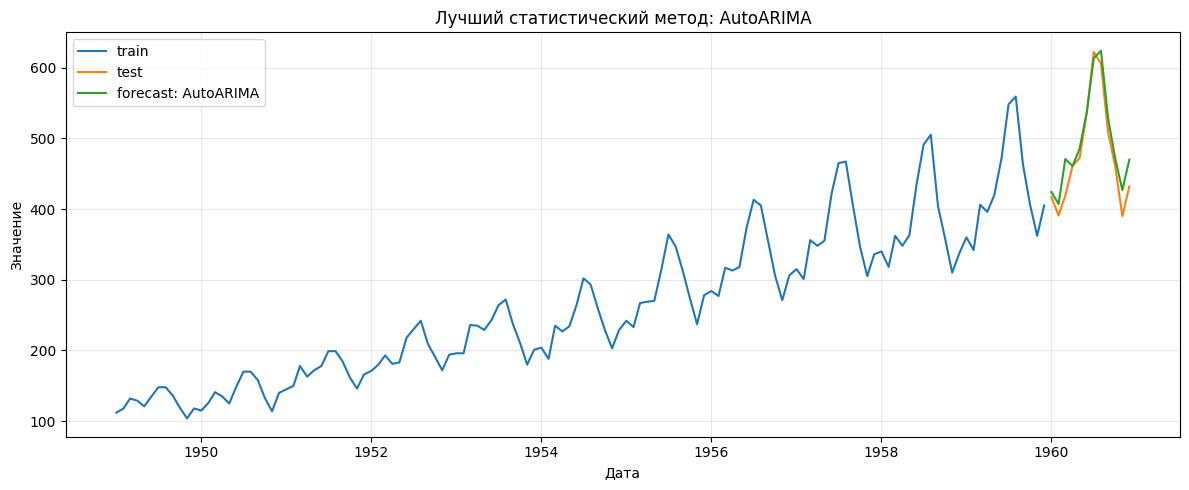

In [6]:
best_model = stats_metrics.iloc[0]['model']

plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label='train')
plt.plot(test.index, test.values, label='test')
plt.plot(test.index, forecast_df[best_model].values, label=f'forecast: {best_model}')
plt.title(f'Лучший статистический метод: {best_model}')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'best_statsforecast_model.png', dpi=150)
plt.show()

### Вывод по графику лучшей модели

На графике видно, что `AutoARIMA` хорошо повторяет общую форму тестового участка: сохраняет восходящий тренд и воспроизводит сезонный пик в середине 1960 года. Прогнозная линия находится близко к фактическим значениям, что согласуется с лучшими метриками RMSE и MAE.

Ошибки все равно есть: модель не идеально попадает в отдельные месяцы, особенно на локальных подъемах и снижениях. Но для горизонта 12 месяцев результат выглядит устойчивым. Важно учитывать, что тестовая выборка состоит только из одного года, поэтому вывод о лидерстве модели лучше воспринимать как результат данного эксперимента, а не как универсальное правило для любых временных рядов.

## Опциональный Prophet

Prophet может быть сложнее установить на Windows. Поэтому он вынесен в отдельный опциональный блок. Если пакет не установлен, блок будет пропущен.

In [7]:
try:
    from prophet import Prophet

    prophet_train = pd.DataFrame({'ds': train.index, 'y': train.values})
    prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    prophet_model.fit(prophet_train)
    future = pd.DataFrame({'ds': test.index})
    prophet_pred = prophet_model.predict(future)['yhat'].values

    prophet_metrics = forecast_metrics(test.values, prophet_pred)
    prophet_metrics['model'] = 'Prophet'
    prophet_metrics['group'] = 'statistical_optional'

    stats_metrics_with_prophet = pd.concat([stats_metrics, pd.DataFrame([prophet_metrics])], ignore_index=True)
    stats_metrics_with_prophet = stats_metrics_with_prophet.sort_values('RMSE')
    stats_metrics_with_prophet.to_csv(REPORT_DIR / 'statsforecast_comparison_with_prophet.csv', index=False)
    display(stats_metrics_with_prophet)
except Exception as e:
    print('Prophet пропущен. Причина:', e)

Importing plotly failed. Interactive plots will not work.


09:24:38 - cmdstanpy - INFO - Chain [1] start processing


09:24:38 - cmdstanpy - INFO - Chain [1] done processing


,MAE,RMSE,MAPE,sMAPE,model,group
0,18.515823,23.919484,4.179693,4.031179,AutoARIMA,statistical
1,19.357397,24.985161,3.919981,3.931008,AutoTheta,statistical
2,35.612471,40.083617,7.206838,7.450637,AutoETS,statistical
6,33.434522,43.067854,6.614230,6.753351,Prophet,statistical_optional
3,47.833333,50.708316,9.987533,10.571808,SeasonalNaive,statistical
4,66.307888,92.666363,12.417957,13.814045,RWD,statistical
5,76.000000,102.976535,14.251338,16.120845,Naive,statistical


## Вывод

Статистические модели дают сильный результат на месячном ряде авиапассажиров. Лучшей по RMSE стала `AutoARIMA`: RMSE = 23.92, MAE = 18.52, MAPE = 4.18%. Почти такой же результат дала `AutoTheta`: RMSE = 24.99, MAPE = 3.92%. При этом по MAPE немного лучше `AutoTheta`: 3.92% против 4.18%, поэтому выбор лучшей модели зависит от основной метрики.

`SeasonalNaive` улучшила результат относительно `Naive`: RMSE снизился со 102.98 до 50.71, то есть на 52.27 пункта или на 50.8%. MAPE снизился с 14.25% до 9.99%, то есть на 4.26 п.п., что подтверждает важность годовой сезонности. `Prophet` запустился как опциональная модель, но уступил AutoARIMA и AutoTheta: RMSE = 43.07.

Итог: для дальнейшего сравнения с ML/DL-подходами стоит использовать `AutoARIMA` как основную статистическую модель и `AutoTheta` как сильную альтернативу. Baseline-модели полезны оставить в отчете как контрольную точку: они показывают минимальный уровень качества, который должна превосходить любая более сложная модель.